1) FINDING THE DFT OF A SINGLE SONG AND PLOTTING IN A GRAPH

In [1]:
#importing libraries
import librosa
import numpy as np
import matplotlib.pyplot as plt



In [2]:
#Loading the song "A Day in the Life"
song_name="A Hard Day_s Night"
path=f"EE200 Project Song Database\{song_name}.mp3"
data,samplerate=librosa.load(path,sr=None)# converts stereo track into mono track
print(f"Sample Rate: {samplerate} Hz")
print(f"Total Samples: {len(data)}")

<string>:3: SyntaxWarning: invalid escape sequence '\{'
<>:3: SyntaxWarning: invalid escape sequence '\{'
<string>:3: SyntaxWarning: invalid escape sequence '\{'
<>:3: SyntaxWarning: invalid escape sequence '\{'
C:\Users\manth\AppData\Local\Temp\ipykernel_24948\265953119.py:3: SyntaxWarning: invalid escape sequence '\{'
  path=f"EE200 Project Song Database\{song_name}.mp3"
c:\Users\manth\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\manth\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\manth\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationW

Sample Rate: 48000 Hz
Total Samples: 7341696


In [3]:
#compute dft using fast fourier transform
N=len(data)
dft_result=np.fft.fft(data)
#calculate the frequency bins
#we take only half of the array because the fft of a real time domain produces a mirrored spectrum
frequencies =np.fft.fftfreq(N,1/samplerate)[:N//2]
magnitude=np.abs(dft_result)[:N//2]

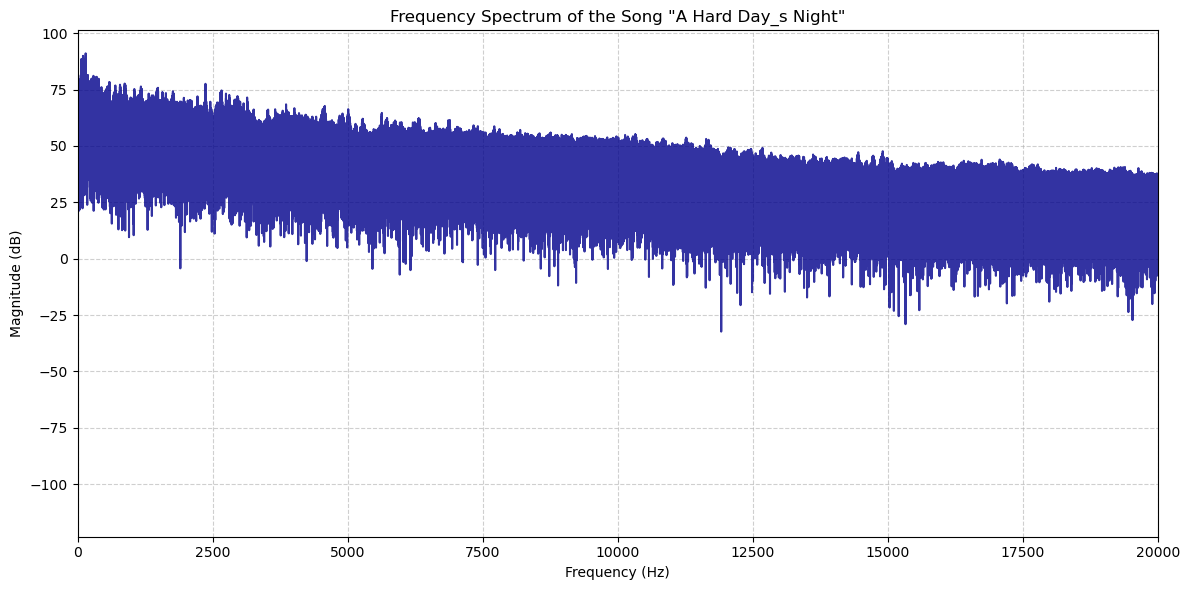

In [4]:
#plotting the graph
plt.figure(figsize=(12, 6))
#convert magnitude to decibel scale
magnitude_db = 20 * np.log10(magnitude + 1e-10)

plt.plot(frequencies, magnitude_db, color='darkblue', alpha=0.8)
plt.title(f"Frequency Spectrum of the Song \"{song_name}\"")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(0,20000)
plt.tight_layout()
plt.show()

2)PLOTTING THE SPECTROGRAM OF A GIVEN SONG
for different window lengths(1024,256, 8192)

In [5]:
#defining the function to plot the 
def spectrogram(path,window_size,hoplength):

    data,samplerate=librosa.load(path,sr=None)
#finding the short-fourier transform
    stft_matrix = librosa.stft(data,n_fft=window_size,hop_length=hoplength)
#convert the magnitude to decibels
    spectrogram_db=librosa.amplitude_to_db(np.abs(stft_matrix),ref=np.max)
    return spectrogram_db,samplerate

def plot_spectrogram(spectrogram_db,hoplength,samplerate,song_name):
    plt.figure(figsize=(12,6))
    librosa.display.specshow(spectrogram_db, 
                         sr=samplerate, 
                         hop_length=hoplength,
                         x_axis='time', 
                         y_axis='linear', 
                         cmap='magma',vmin=-80, vmax=0)

    plt.colorbar(format='%+2.0f dB', label='Magnitude (dB)')
    plt.ylim(0,3500)
    plt.xlim(0,25)
    plt.title(f'Spectrogram of "{song_name}"')
    plt.xlabel('Time (Seconds)')
    plt.ylabel('Frequency (Hz)')
    plt.tight_layout()
    plt.show()



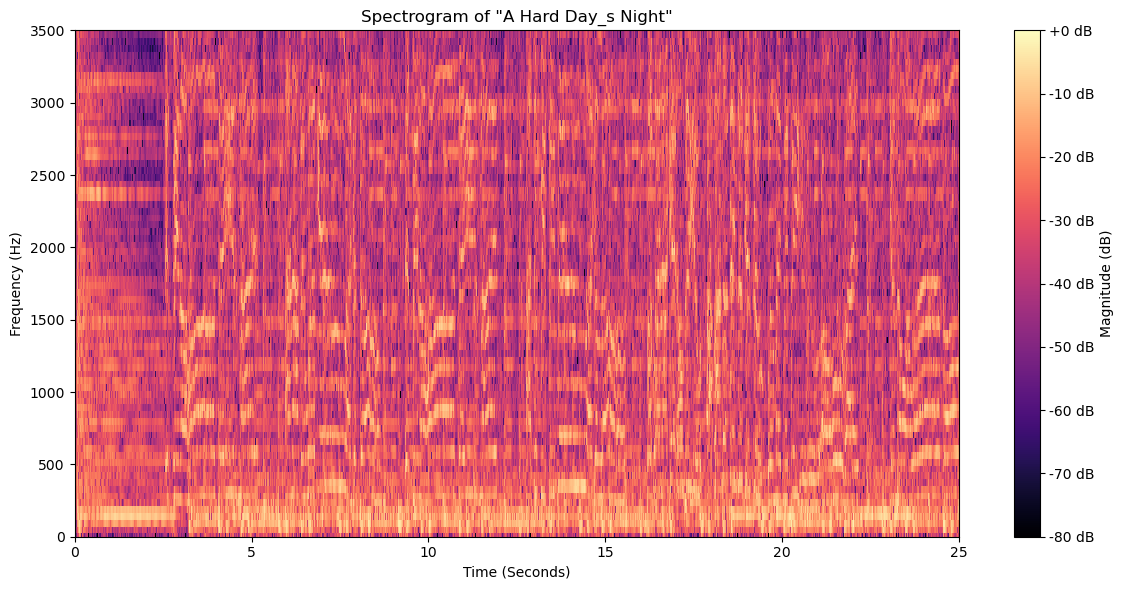

In [6]:
window_size=1024
hop_length=window_size//4
spectrogram_db,samplerate=spectrogram(path,window_size,hop_length)
plot_spectrogram(spectrogram_db,hop_length,samplerate,song_name)

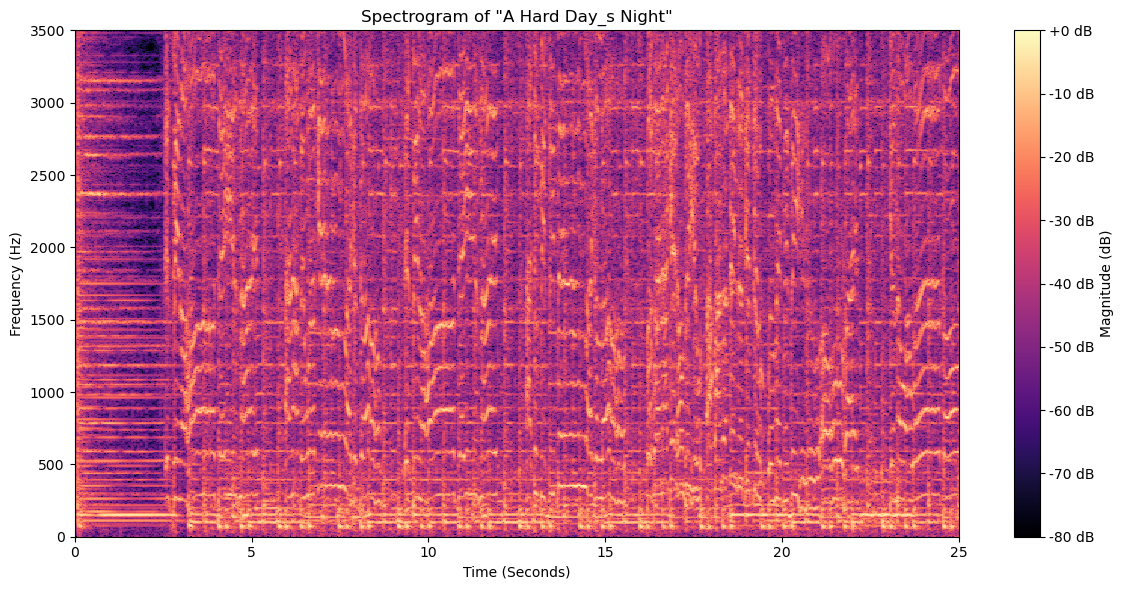

In [7]:
window_size=8192
hop_length=window_size//4
spectrogram_db,samplerate=spectrogram(path,window_size,hop_length)
plot_spectrogram(spectrogram_db,hop_length,samplerate,song_name)


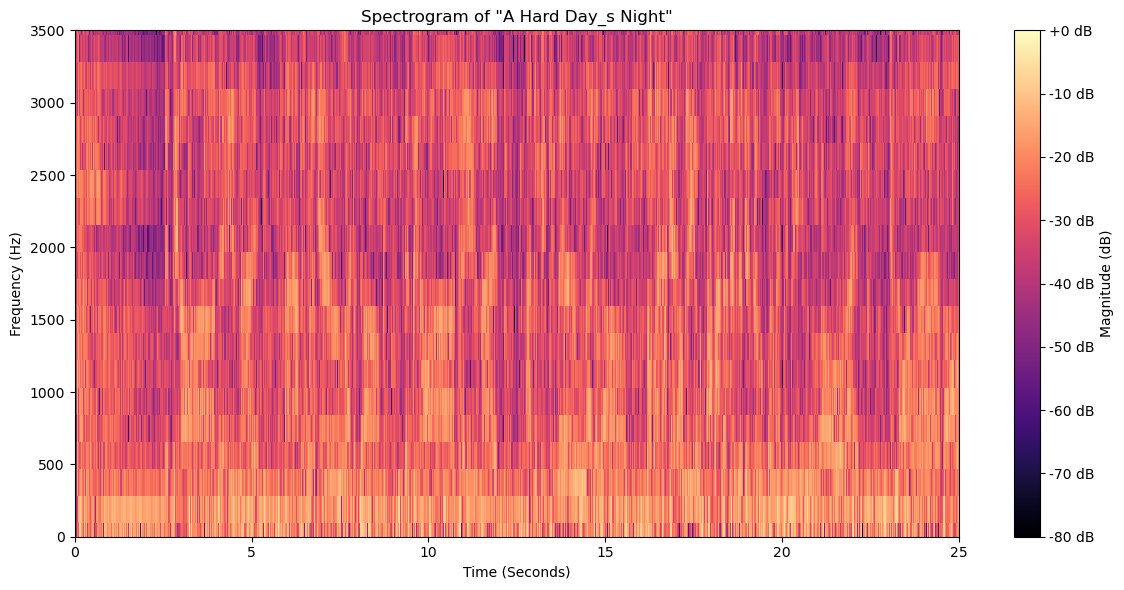

In [8]:
window_size=256
hop_length=window_size//4
spectrogram_db,samplerate=spectrogram(path,window_size,hop_length)
plot_spectrogram(spectrogram_db,hop_length,samplerate,song_name)

3) PLOTTING THE CONSTELLATION OF PEAKS

In [9]:
from scipy.ndimage import maximum_filter

In [10]:
#function to get peak points
def get_peaks(path,window_size,hoplength,neighborhood_size=20,threshold_db=-55):
    spectrogram_db,samplerate=spectrogram(path,window_size,hoplength)
    local_max = maximum_filter(spectrogram_db, size=neighborhood_size)
    # a point is  peak where the point is equal to local maximum and > threshhold
    is_peak = (spectrogram_db == local_max) & (spectrogram_db > threshold_db)
    peak_freq_bins, peak_time_frames = np.where(is_peak)
    #converting the indices to physical units
    times = librosa.frames_to_time(peak_time_frames, sr=samplerate, hop_length=hoplength)
    freqs = librosa.fft_frequencies(sr=samplerate, n_fft=window_size)[peak_freq_bins]
    return spectrogram_db,times,freqs,samplerate
#plotting the constellation of peaks
def plot_constellation_of_peaks(spectrogram_db,times,freqs,hoplength,song_name,samplerate):
    plt.figure(figsize=(12,6))
    librosa.display.specshow(spectrogram_db, sr=samplerate, hop_length=hoplength, 
                         x_axis='time', y_axis='linear', cmap='magma',
                         vmin=-80, vmax=0)
    plt.colorbar(format='%+2.0f dB', label='magnitude (dB)')
    plt.scatter(times, freqs, facecolors='none', edgecolors='cyan', s=30, alpha=0.8, linewidths=1)
    plt.ylim(0, 3500)  
    plt.xlim(0, 25)    
    plt.ylabel('frequency (Hz)')
    plt.xlabel('time (s)')
    plt.title(f'Spectrogram with Local Maxima Constellation Overlay of the song "{song_name}"')
    plt.tight_layout()
    plt.show()

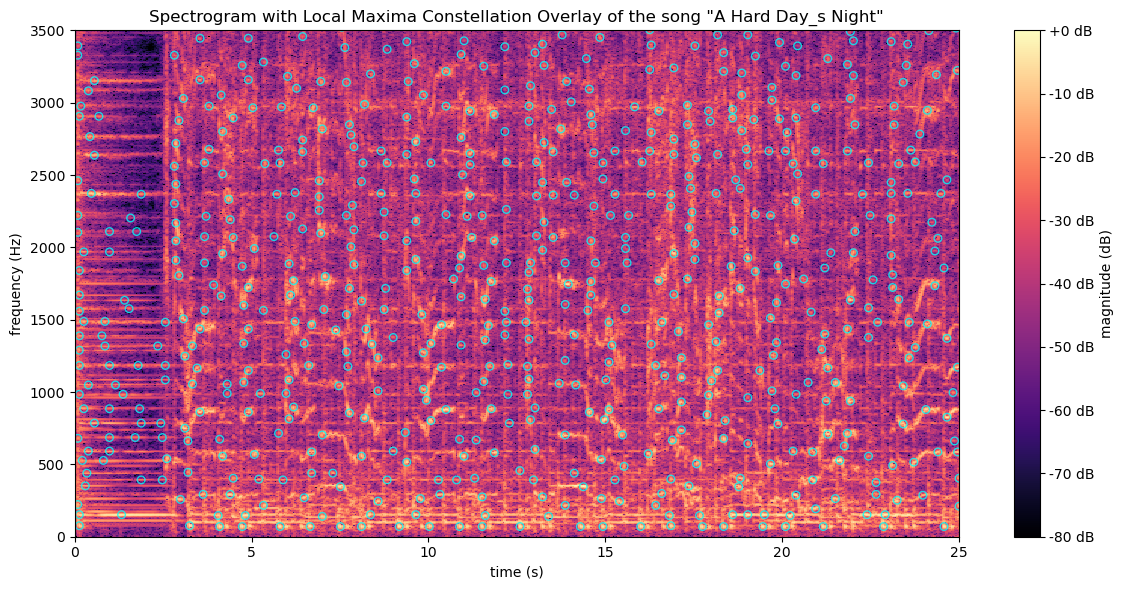

In [11]:
window_size=8192
hop_length=window_size//4
spectrogram_db,times,freqs,samplerate=get_peaks(path,window_size,hop_length)
plot_constellation_of_peaks(spectrogram_db,times,freqs,hop_length,song_name,samplerate)

4) HASHING NEARBY PEAKS AND STORING THEM IN A DATABASE:


In [12]:
import hashlib
import sqlite3
import numpy as np
from pathlib import Path
import os 

import streamlit as st


In [13]:
def setup_database(db_path):

    conn = sqlite3.connect(db_path)

    cursor = conn.cursor()

    cursor.execute('''

        CREATE TABLE IF NOT EXISTS fingerprints (

            hash TEXT,

            song_id TEXT,

            offset REAL

        )

    ''')

    cursor.execute('CREATE INDEX IF NOT EXISTS idx_hash ON fingerprints(hash)')

    conn.commit()

    return conn

In [14]:
#storing the fingerprints in the database
def store_song_fingerprints(conn,times, freqs, song_name):
    peaks = sorted(zip(times, freqs), key=lambda x: x[0])
    cursor=conn.cursor()
    #hashing parameters
    fan_value = 15
    min_time_delta = 0.05
    max_time_delta = 3.0
    hashes_to_insert = []
    for i in range(len(peaks)):
        anchor_time, anchor_freq = peaks[i]
        
        matches = 0
        for j in range(i + 1, len(peaks)):
            target_time, target_freq = peaks[j]
            time_delta = target_time - anchor_time
            
            if time_delta < min_time_delta:
                continue
            if time_delta > max_time_delta:
                break
            f1 = int(anchor_freq)
            f2 = int(target_freq)
            dt = round(time_delta, 3) # Round time difference to milliseconds
            
            # Create signature and hash
            signature = f"{f1}|{f2}|{dt}"
            compact_hash = hashlib.sha1(signature.encode('utf-8')).hexdigest()[:8]
            
            # Append to our batch list (rounding anchor time for clean DB storage)
            hashes_to_insert.append((compact_hash, song_name, round(anchor_time, 3)))
            
            matches += 1
            if matches >= fan_value:
                break
        
        #inserting the batch into database
    cursor.executemany('''
        INSERT INTO fingerprints (hash, song_id, offset)
         VALUES (?, ?, ?)
    ''', hashes_to_insert)
    conn.commit()
    return len(hashes_to_insert)

In [15]:
#stores the fingerprints of all the songs in the database
def process_song_database(folder_path, db_name="song_database.db"):
    
    
    # Audio parameters
    WINDOW_SIZE = 4096
    HOP_LENGTH = WINDOW_SIZE//4
    
    folder = Path(folder_path)
    
    if not folder.exists() or not folder.is_dir():
        print(f"Error: The directory '{folder_path}' does not exist.")
        return
        
    # Find all common audio files in the folder
    audio_extensions = ['*.mp3', '*.wav', '*.flac']
    song_files = []
    for ext in audio_extensions:
        song_files.extend(folder.glob(ext))
        
    if not song_files:
        print(f"No audio files found in '{folder_path}'.")
        return

    print(f"Found {len(song_files)} songs. Initializing database...")
    conn = setup_database(db_name)
    
    total_hashes = 0
    
    for idx, filepath in enumerate(song_files, 1):
        # Use the filename (without extension) as the unique song identifier
        song_name = filepath.stem 
        print(f"[{idx}/{len(song_files)}] Processing '{song_name}'...")
        
        try:
            _,times, freqs,_ = get_peaks(filepath, WINDOW_SIZE, HOP_LENGTH,neighborhood_size=50,threshold_db=-25)
            num_hashes = store_song_fingerprints(conn, times, freqs, song_name)
            total_hashes += num_hashes
            print(f"    -> Generated {num_hashes} hashes.")
        except Exception as e:
            print(f"    -> Error processing '{song_name}': {e}")
            
    conn.close()
    print("-" * 40)
    print(f"Processing Complete! Stored a total of {total_hashes} hashes in '{db_name}'.")

In [16]:
SONG_FOLDER="EE200 Project Song Database"
DATABASE_FILE="song_database.db"
process_song_database(SONG_FOLDER,DATABASE_FILE)

Found 50 songs. Initializing database...
[1/50] Processing 'A Day In The Life'...
    -> Generated 9527 hashes.
[2/50] Processing 'A Hard Day_s Night'...
    -> Generated 17799 hashes.
[3/50] Processing 'Across The Universe'...
    -> Generated 12718 hashes.
[4/50] Processing 'Back In The U.S.S.R.'...
    -> Generated 11130 hashes.
[5/50] Processing 'Blackbird'...
    -> Generated 2645 hashes.
[6/50] Processing 'Bohemian Rhapsody'...
    -> Generated 13331 hashes.
[7/50] Processing 'Can_t Buy Me Love'...
    -> Generated 14147 hashes.
[8/50] Processing 'Crazy Little Thing Called Love'...
    -> Generated 10754 hashes.
[9/50] Processing 'Day Tripper'...
    -> Generated 18763 hashes.
[10/50] Processing 'Don_t Stop Me Now'...
    -> Generated 24081 hashes.
[11/50] Processing 'Drive My Car'...
    -> Generated 16405 hashes.
[12/50] Processing 'Eight Days A Week'...
    -> Generated 17221 hashes.
[13/50] Processing 'Eleanor Rigby'...
    -> Generated 7854 hashes.
[14/50] Processing 'Get Ba

4) IDENTIYING AN UNKNOWN CLIP BY MATCHING THE HASHES

In [17]:
#generating hashes for the unknown clip
def generate_clip_hashes(times, freqs):
    
    peaks = sorted(zip(times, freqs), key=lambda x: x[0])
    
    fan_value = 15
    min_time_delta = 0.05
    max_time_delta = 3.0
    
    clip_hashes = []
    
    for i in range(len(peaks)):
        anchor_time, anchor_freq = peaks[i]
        
        matches = 0
        for j in range(i + 1, len(peaks)):
            target_time, target_freq = peaks[j]
            time_delta = target_time - anchor_time
            
            if time_delta < min_time_delta:
                continue
            if time_delta > max_time_delta:
                break
                
            f1 = int(anchor_freq)
            f2 = int(target_freq)
            dt = round(time_delta, 3) 
            
            signature = f"{f1}|{f2}|{dt}"
            compact_hash = hashlib.sha1(signature.encode('utf-8')).hexdigest()[:8]
            clip_hashes.append((compact_hash, round(anchor_time, 3)))
            
            matches += 1
            if matches >= fan_value:
                break
                
    return clip_hashes

In [18]:
from collections import Counter

In [19]:
#functions that identifies song
def match_audio_clip(clip_path, db_path="song_database.db"):
    #idenitfying songs by analyszing hash time offsets"
    print(f"Analyzing unknown clip: '{clip_path}'...")
    
    WINDOW_SIZE = 4096
    HOP_LENGTH = WINDOW_SIZE // 4
    _, times, freqs, _ = get_peaks(
        clip_path, 
        WINDOW_SIZE, 
        HOP_LENGTH, 
        neighborhood_size=50, 
        threshold_db=-25
    )
    
    # Generate hashes for the clip
    clip_hashes = generate_clip_hashes(times, freqs)
    
    if not clip_hashes:
        print("Could not extract any clear hashes from the clip.")
        return None
        
    # Group clip offsets by hash for extremely fast lookup
    clip_hash_dict = {}
    for h, offset in clip_hashes:
        if h not in clip_hash_dict:
            clip_hash_dict[h] = []
        clip_hash_dict[h].append(offset)
        
    unique_hashes = list(clip_hash_dict.keys())
    
    # Query the database
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # We use a Counter to build our Histogram of Relative Offsets
    alignment_histogram = Counter()
    
    #chunking our queries
    chunk_size = 900
    for i in range(0, len(unique_hashes), chunk_size):
        chunk = unique_hashes[i:i + chunk_size]
        placeholders = ','.join(['?'] * len(chunk))
        
        query = f"SELECT hash, song_id, offset FROM fingerprints WHERE hash IN ({placeholders})"
        
        for row in cursor.execute(query, chunk):
            db_hash, song_id, db_offset = row
            
            # 4. The Alignment Logic
            # Compare the database offset to every time that hash appeared in the clip
            for clip_offset in clip_hash_dict[db_hash]:
                # Calculate the relative time offset (db_offset - clip_offset)
                relative_offset = round(db_offset - clip_offset, 1)
                alignment_histogram[(song_id, relative_offset)] += 1
                
    conn.close()
    
    # 5. Determine the matched song
    if not alignment_histogram:
        print("No matches found in the database.")
        return None
        
    # the matched song is the bin with the highest number of alligned hashes
    best_match, max_score = alignment_histogram.most_common(1)[0]
    matched_song = best_match[0]
    matched_offset = best_match[1]
    
    print("-" * 40)
    print(f"✅ MATCH FOUND: {matched_song}")
    print(f"   -> Alignment Score: {max_score} synchronized hashes")
    print(f"   -> Clip starts at ~{matched_offset} seconds into the song")
    print("-" * 40)
    
    return matched_song,alignment_histogram



In [20]:
#plots the offset histogram
#it plots and finds the time stamp from which the clip is clipped from the original song
def plot_offset_histogram(alignment_histogram, matched_song):
  
    if not alignment_histogram or not matched_song:
        return
        
    # Filter the data
    offsets = []
    scores = []
    
    for (song_id, offset), count in alignment_histogram.items():
        if song_id == matched_song:
            offsets.append(offset)
            scores.append(count)
            
    if not offsets:
        return

    plt.figure(figsize=(12, 6))
    # Plot the offsets as a bar chart 
    plt.bar(offsets, scores, width=0.2, color='royalblue', alpha=0.8)
    # Find and highlight the winning spike
    max_score = max(scores)
    winning_offset = offsets[scores.index(max_score)]
    # plt.axvline(x=winning_offset, color='red', linestyle='--', linewidth=2,
    #             label=f'True Alignment Offset ({winning_offset}s)')
    plt.title(f"Histogram of Relative Time Offsets: '{matched_song}'", fontsize=14, fontweight='bold')
    plt.xlabel("Relative Time Offset (Database Time - Clip Time) in Seconds", fontsize=12)
    plt.ylabel("Number of Synchronized Hashes", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    # Force the plot to show the full scale so you can see how 'flat' it really is
    # plt.ylim(0, 5) # Assuming 600 was your peak height from the match
    plt.tight_layout()
    plt.show()

Analyzing unknown clip: 'test/unknown.mp3'...
----------------------------------------
✅ MATCH FOUND: Drive My Car
   -> Alignment Score: 4472 synchronized hashes
   -> Clip starts at ~60.1 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


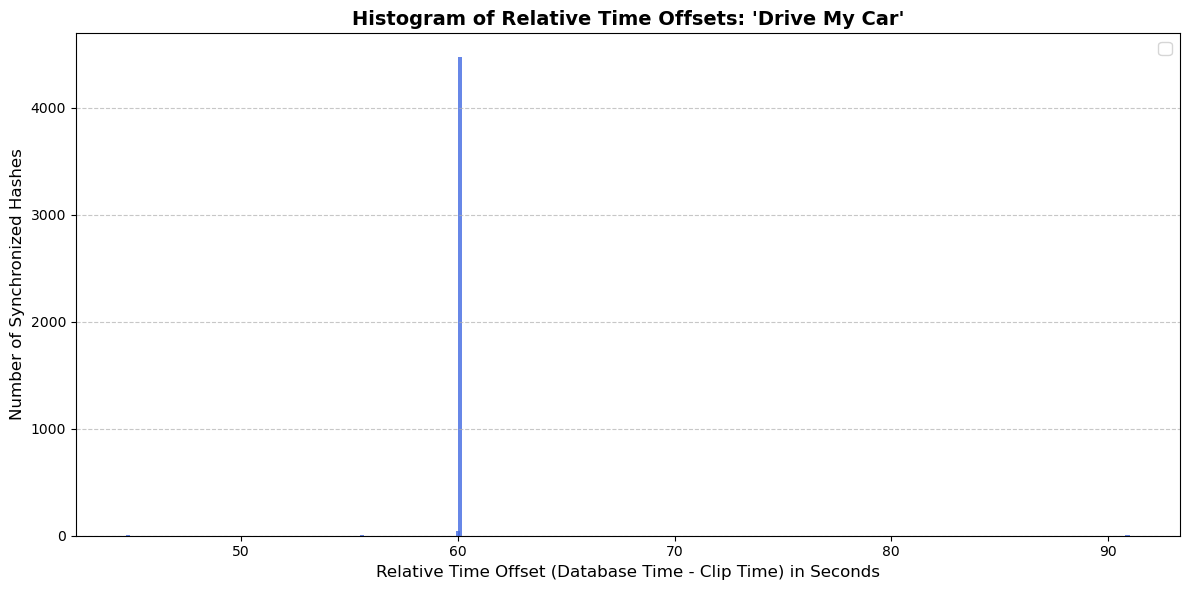

In [21]:
#TESTING : A 10 second clip is clipped from the song "Drive my Car" to check if the identifier is correctly identifying 
#The clip is  from 1:00 to 1:10
unknown_song="unknown"
unknown_path=f"test/{unknown_song}.mp3"
song_name,histogram_data=match_audio_clip(unknown_path,DATABASE_FILE)
if song_name:
    plot_offset_histogram(histogram_data,song_name)
    #plotting the histogram with the wrong song


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


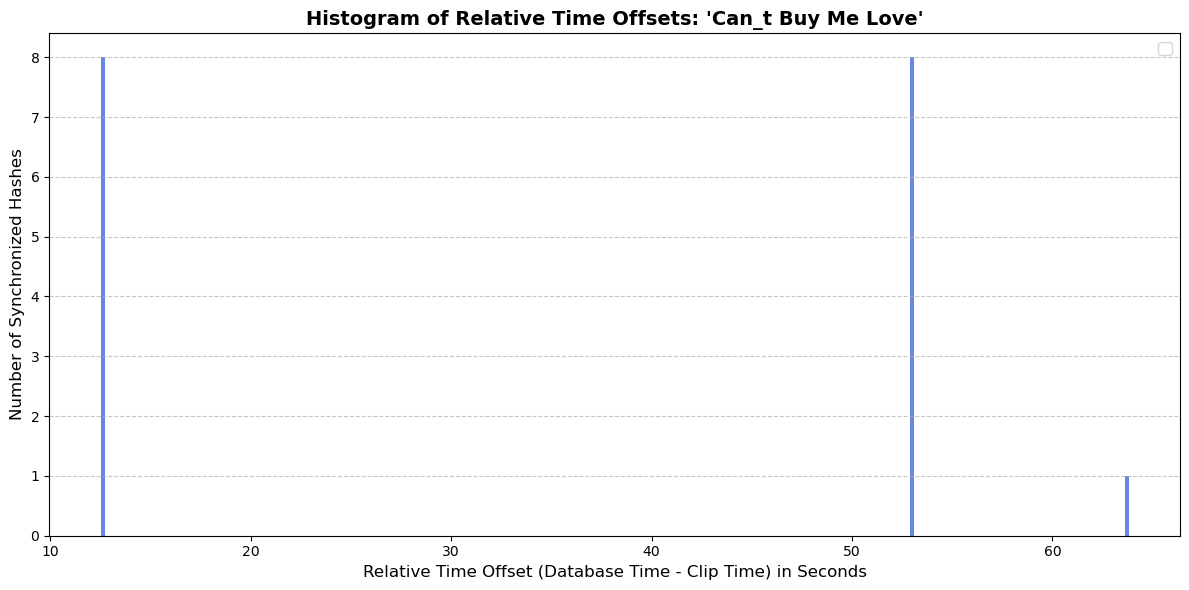

In [22]:
#plotting the histogram for the wrong song
plot_offset_histogram(histogram_data, "Can_t Buy Me Love")

In [23]:
#matching single peaks only
def store_single_peaks(conn, times, freqs, song_name):
    cursor = conn.cursor()
    hashes_to_insert = []
    
    # Notice the absence of nested loops! We just hash the raw frequency.
    for time, freq in zip(times, freqs):
        f1 = int(freq)
        signature = f"{f1}"
        compact_hash = hashlib.sha1(signature.encode('utf-8')).hexdigest()[:8]
        hashes_to_insert.append((compact_hash, song_name, round(time, 3)))
        
    cursor.executemany('''
        INSERT INTO fingerprints (hash, song_id, offset)
        VALUES (?, ?, ?)
    ''', hashes_to_insert)
    conn.commit()
    return len(hashes_to_insert)

In [24]:
def process_single_peak_database(folder_path, db_name="single_peak_db.db"):
    WINDOW_SIZE = 4096
    HOP_LENGTH = WINDOW_SIZE // 4
    folder = Path(folder_path)
    
    if not folder.exists() or not folder.is_dir():
        print(f"Error: Directory '{folder_path}' not found.")
        return
        
    song_files = []
    for ext in ['*.mp3', '*.wav', '*.flac']:
        song_files.extend(folder.glob(ext))

    print(f"Initializing SINGLE PEAK database for {len(song_files)} songs...")
    conn = setup_database(db_name)
    total_hashes = 0
    
    for idx, filepath in enumerate(song_files, 1):
        song_name = filepath.stem 
        try:
            _, times, freqs, _ = get_peaks(filepath, WINDOW_SIZE, HOP_LENGTH)
            num_hashes = store_single_peaks(conn, times, freqs, song_name)
            total_hashes += num_hashes
            print(f"[{idx}/{len(song_files)}] '{song_name}' -> {num_hashes} peaks stored.")
        except Exception as e:
            print(f"[{idx}/{len(song_files)}] Error on '{song_name}': {e}")
            
    conn.close()
    print(f"Complete! Stored {total_hashes} single-peak hashes in '{db_name}'.")


In [25]:

def match_single_peak_clip(clip_path, db_path="single_peak_db.db"):
    print(f"\nAnalyzing clip with SINGLE PEAKS: '{clip_path}'...")
    
    WINDOW_SIZE = 4096
    HOP_LENGTH = WINDOW_SIZE // 4
    _, times, freqs, _ = get_peaks(clip_path, WINDOW_SIZE, HOP_LENGTH)
    
    # Generate single peak hashes for the clip
    clip_hash_dict = {}
    for time, freq in zip(times, freqs):
        f1 = int(freq)
        signature = f"{f1}"
        compact_hash = hashlib.sha1(signature.encode('utf-8')).hexdigest()[:8]
        
        if compact_hash not in clip_hash_dict:
            clip_hash_dict[compact_hash] = []
        clip_hash_dict[compact_hash].append(round(time, 3))
        
    unique_hashes = list(clip_hash_dict.keys())
    
    if not unique_hashes:
        print("No peaks found in clip.")
        return None, None

    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    alignment_histogram = Counter()
    
    chunk_size = 900
    for i in range(0, len(unique_hashes), chunk_size):
        chunk = unique_hashes[i:i + chunk_size]
        placeholders = ','.join(['?'] * len(chunk))
        query = f"SELECT hash, song_id, offset FROM fingerprints WHERE hash IN ({placeholders})"
        
        for row in cursor.execute(query, chunk):
            db_hash, song_id, db_offset = row
            for clip_offset in clip_hash_dict[db_hash]:
                relative_offset = round(db_offset - clip_offset, 1)
                alignment_histogram[(song_id, relative_offset)] += 1
                
    conn.close()
    
    if not alignment_histogram:
        print("No matches found in database.")
        return None, None
        
    best_match, max_score = alignment_histogram.most_common(1)[0]
    matched_song = best_match[0]
    
    print("-" * 40)
    print(f"SINGLE PEAK WINNER: {matched_song}")
    print(f"Score: {max_score} synchronized hashes")
    print("-" * 40)
    
    return matched_song, alignment_histogram

In [44]:

def plot_single_histogram(alignment_histogram, matched_song):
    if not alignment_histogram or not matched_song:
        return
        
    offsets = []
    scores = []
    
    for (song_id, offset), count in alignment_histogram.items():
        if song_id == matched_song:
            offsets.append(offset)
            scores.append(count)
            
    if not offsets:
        return

    plt.figure(figsize=(12, 6))
    plt.bar(offsets, scores, width=0.5, color='darkorange', alpha=0.8)
    
    max_score = max(scores)
    winning_offset = offsets[scores.index(max_score)]
    
    # plt.axvline(x=winning_offset, color='black', linestyle='--', linewidth=2,
    #             label=f'Winning Offset ({winning_offset}s)')
    
    plt.title(f"SINGLE PEAK Histogram: '{matched_song}'", fontsize=14, fontweight='bold')
    plt.xlabel("Relative Time Offset (Seconds)", fontsize=12)
    plt.ylabel("Number of Synchronized Hashes", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

In [27]:
SINGLE_PEAK_DATABASE_FILE="single_peak_db.db"
process_single_peak_database(SONG_FOLDER,SINGLE_PEAK_DATABASE_FILE)


Initializing SINGLE PEAK database for 50 songs...
[1/50] 'A Day In The Life' -> 32385 peaks stored.
[2/50] 'A Hard Day_s Night' -> 23923 peaks stored.
[3/50] 'Across The Universe' -> 19044 peaks stored.
[4/50] 'Back In The U.S.S.R.' -> 17716 peaks stored.
[5/50] 'Blackbird' -> 9773 peaks stored.
[6/50] 'Bohemian Rhapsody' -> 19195 peaks stored.
[7/50] 'Can_t Buy Me Love' -> 22646 peaks stored.
[8/50] 'Crazy Little Thing Called Love' -> 19451 peaks stored.
[9/50] 'Day Tripper' -> 22225 peaks stored.
[10/50] 'Don_t Stop Me Now' -> 26217 peaks stored.
[11/50] 'Drive My Car' -> 20410 peaks stored.
[12/50] 'Eight Days A Week' -> 21324 peaks stored.
[13/50] 'Eleanor Rigby' -> 11090 peaks stored.
[14/50] 'Get Back' -> 16365 peaks stored.
[15/50] 'Hello, Goodbye' -> 30738 peaks stored.
[16/50] 'Help!' -> 22539 peaks stored.
[17/50] 'Helter Skelter' -> 27587 peaks stored.
[18/50] 'Hey Jude' -> 58294 peaks stored.
[19/50] 'I Am The Walrus' -> 32192 peaks stored.
[20/50] 'I Saw Her Standing There


Analyzing clip with SINGLE PEAKS: 'test/unknown.mp3'...
----------------------------------------
SINGLE PEAK WINNER: Drive My Car
Score: 7567 synchronized hashes
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\175868045.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


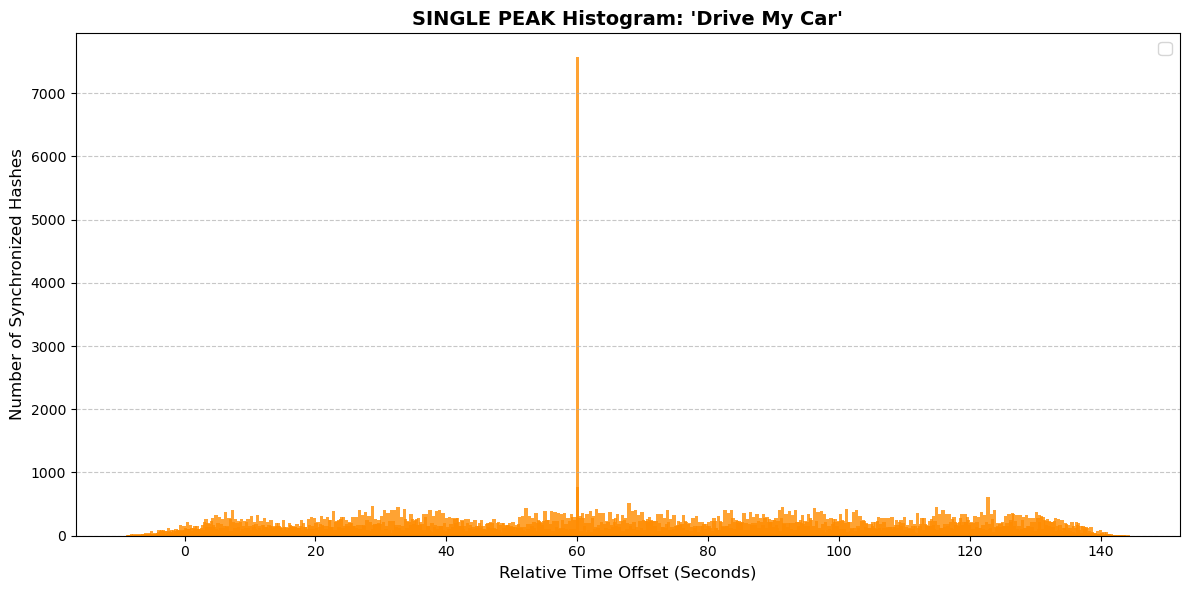

In [45]:
song_name,hist_data=match_single_peak_clip(unknown_path,SINGLE_PEAK_DATABASE_FILE)
if song_name:
    plot_single_histogram(hist_data, song_name)

In [29]:
import soundfile as sf

In [30]:
#testing on the same 10 second clip of "Drive my Car" song
#creating three different clips with increased noise ,shifted  pitch and strteched time
def add_noise(clean_clip_path,level):
    
    #creating file with increased noise
    y, sr = librosa.load(clean_clip_path, sr=None, mono=True)
    temp_file_1 = "unknown_clip_with_noise.wav"
    #adding noise
    print("1)Adding Noise")
    # Fraction of max amplitude
    
    max_amp = np.max(np.abs(y))
   
        # Generate random noise and scale it
    noise = np.random.randn(len(y))
    noisy_y = y + (noise * max_amp * level)
        
        # Save and test
    sf.write(temp_file_1, noisy_y, sr)
    print(f"\nNoise Level: {level*100}% of max amplitude")
     

In [31]:
#function to shift pitch
def add_shifted_pitch(clean_clip_path,shift):
    y, sr = librosa.load(clean_clip_path, sr=None, mono=True)
    #creating files with shifted pitch
    temp_file_2 = "unknown_clip_with_shiftedpitch.wav"
    print("2)PITCH SHIFTING ")
    #shifts the pitch
    shifted_y = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=shift)
    sf.write(temp_file_2, shifted_y, sr)
    print(f"\nPitch Shift: +{shift} semitones")

In [32]:
#function to stretch time(increasing or decrease the tempo)
# Rates > 1.0 are faster, < 1.0 are slower
def add_streteched_time(clean_clip_path,rate):
    y, sr = librosa.load(clean_clip_path, sr=None, mono=True)
    #creating file with stretched time
    print("3) TIME STRETCHING")
    temp_file_3 = "unknown_clip_with_stretched_time.wav"
    stretched_y = librosa.effects.time_stretch(y=y, rate=rate)
    sf.write(temp_file_3, stretched_y, sr)  
    print(f"\nTime Stretch: {rate}x speed")

1)Adding Noise

Noise Level: 1.0% of max amplitude
Analyzing unknown clip: 'unknown_clip_with_noise.wav'...
----------------------------------------
✅ MATCH FOUND: Drive My Car
   -> Alignment Score: 4832 synchronized hashes
   -> Clip starts at ~60.1 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


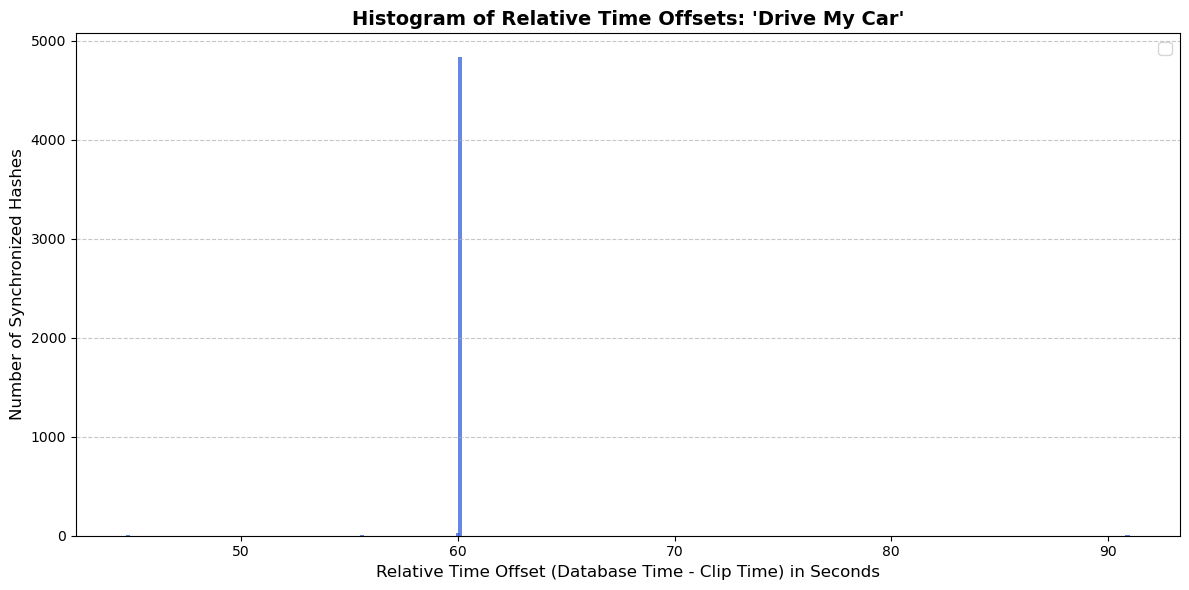

In [33]:
temp_file_1 = "unknown_clip_with_noise.wav"
add_noise(unknown_path,0.01)
song_name, histogram = match_audio_clip(temp_file_1, DATABASE_FILE)
plot_offset_histogram(histogram, song_name)


1)Adding Noise

Noise Level: 5.0% of max amplitude
Analyzing unknown clip: 'unknown_clip_with_noise.wav'...
----------------------------------------
✅ MATCH FOUND: Drive My Car
   -> Alignment Score: 4080 synchronized hashes
   -> Clip starts at ~60.1 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


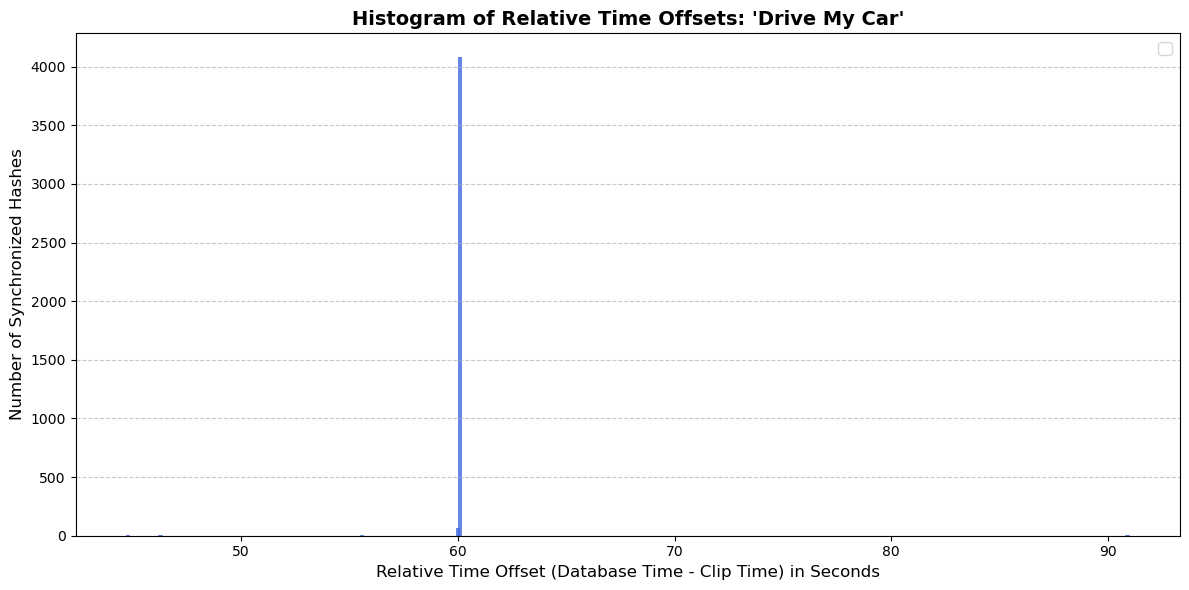

In [34]:
temp_file_1 = "unknown_clip_with_noise.wav"
add_noise(unknown_path,0.05)
song_name, histogram = match_audio_clip(temp_file_1, DATABASE_FILE)
plot_offset_histogram(histogram, song_name)


1)Adding Noise

Noise Level: 10.0% of max amplitude
Analyzing unknown clip: 'unknown_clip_with_noise.wav'...
----------------------------------------
✅ MATCH FOUND: Drive My Car
   -> Alignment Score: 2432 synchronized hashes
   -> Clip starts at ~60.1 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


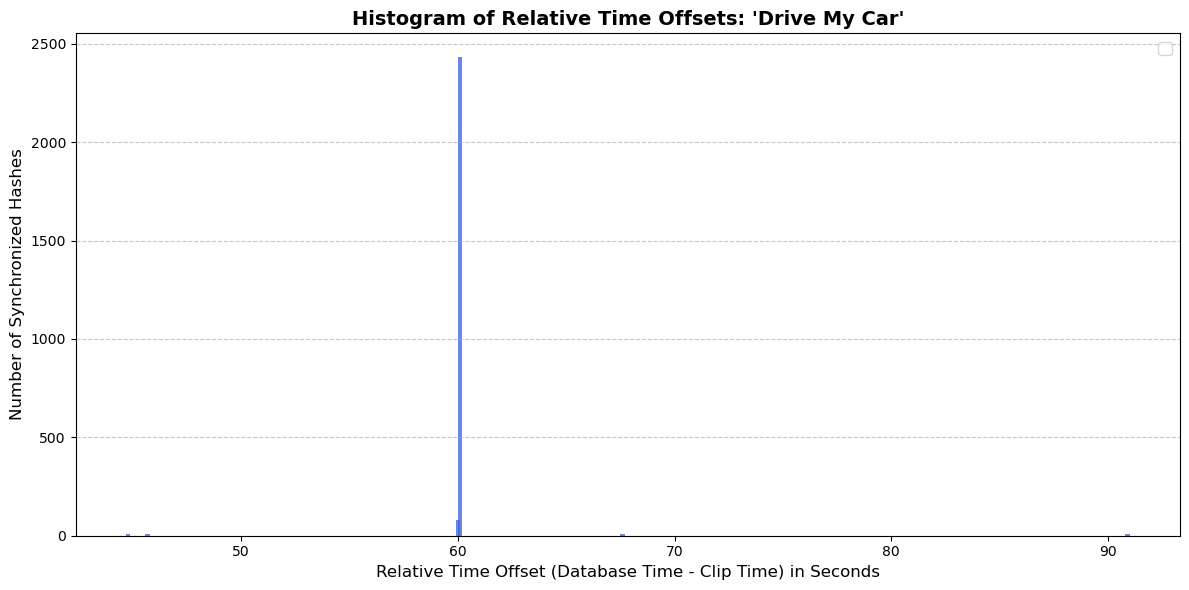

In [35]:
temp_file_1 = "unknown_clip_with_noise.wav"
add_noise(unknown_path,0.1)
song_name, histogram = match_audio_clip(temp_file_1, DATABASE_FILE)
plot_offset_histogram(histogram, song_name)


1)Adding Noise

Noise Level: 20.0% of max amplitude
Analyzing unknown clip: 'unknown_clip_with_noise.wav'...
----------------------------------------
✅ MATCH FOUND: Drive My Car
   -> Alignment Score: 312 synchronized hashes
   -> Clip starts at ~60.1 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


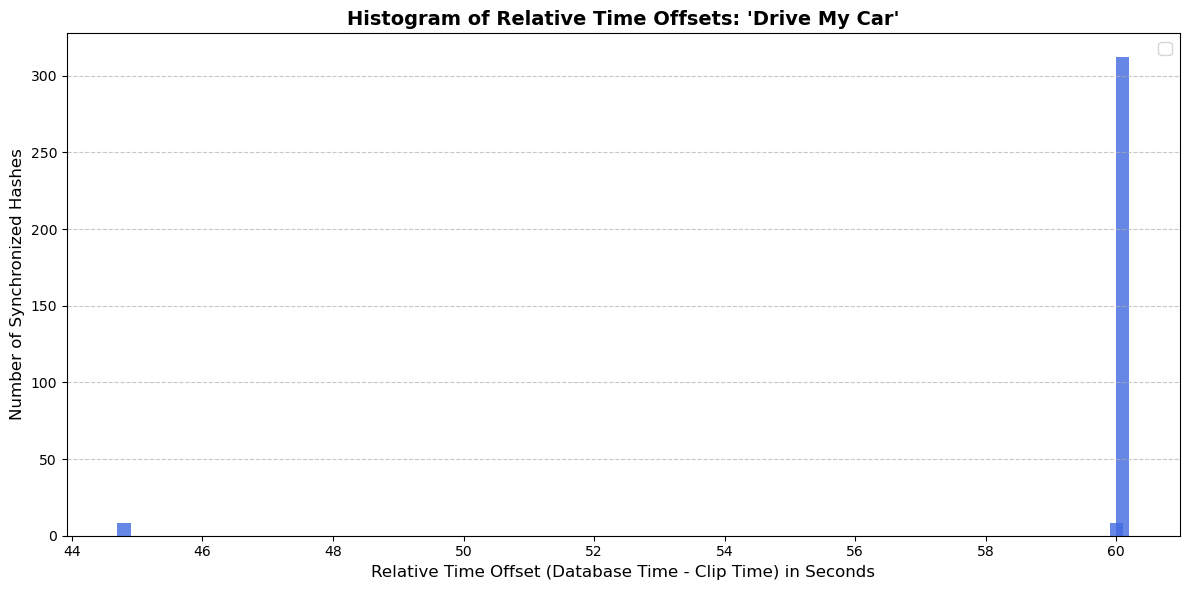

In [36]:
temp_file_1 = "unknown_clip_with_noise.wav"
add_noise(unknown_path,0.2)
song_name, histogram = match_audio_clip(temp_file_1, DATABASE_FILE)
plot_offset_histogram(histogram, song_name)


1)Adding Noise

Noise Level: 30.0% of max amplitude
Analyzing unknown clip: 'unknown_clip_with_noise.wav'...
----------------------------------------
✅ MATCH FOUND: Drive My Car
   -> Alignment Score: 192 synchronized hashes
   -> Clip starts at ~60.1 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


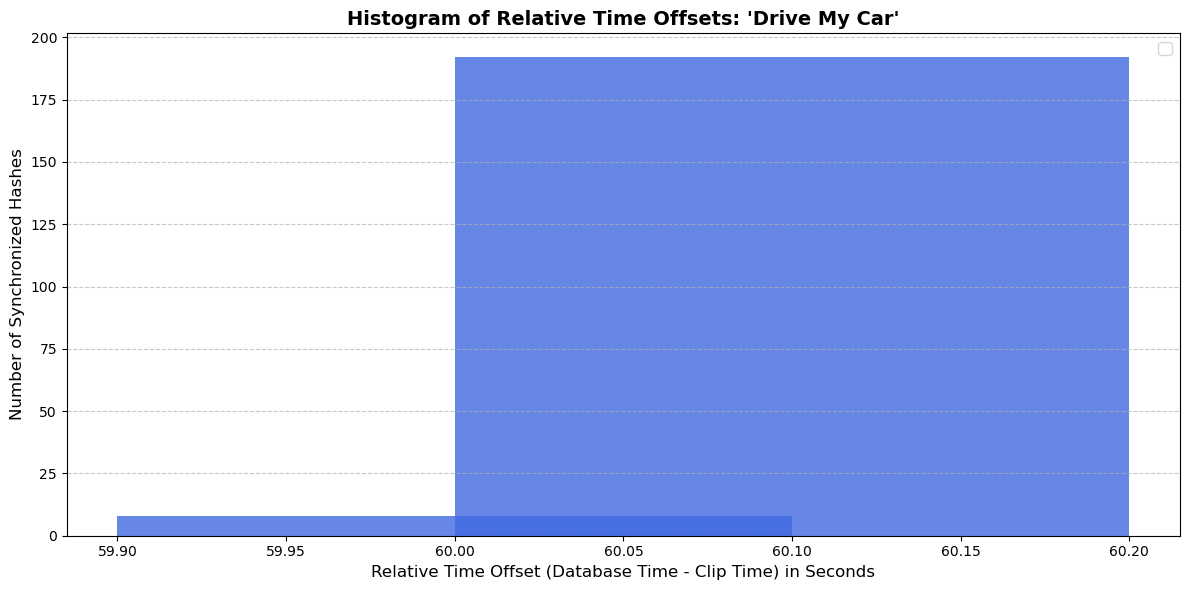

In [37]:
temp_file_1 = "unknown_clip_with_noise.wav"
add_noise(unknown_path,0.3)
song_name, histogram = match_audio_clip(temp_file_1, DATABASE_FILE)
plot_offset_histogram(histogram, song_name)


1)Adding Noise

Noise Level: 40.0% of max amplitude
Analyzing unknown clip: 'unknown_clip_with_noise.wav'...
----------------------------------------
✅ MATCH FOUND: Drive My Car
   -> Alignment Score: 80 synchronized hashes
   -> Clip starts at ~60.1 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


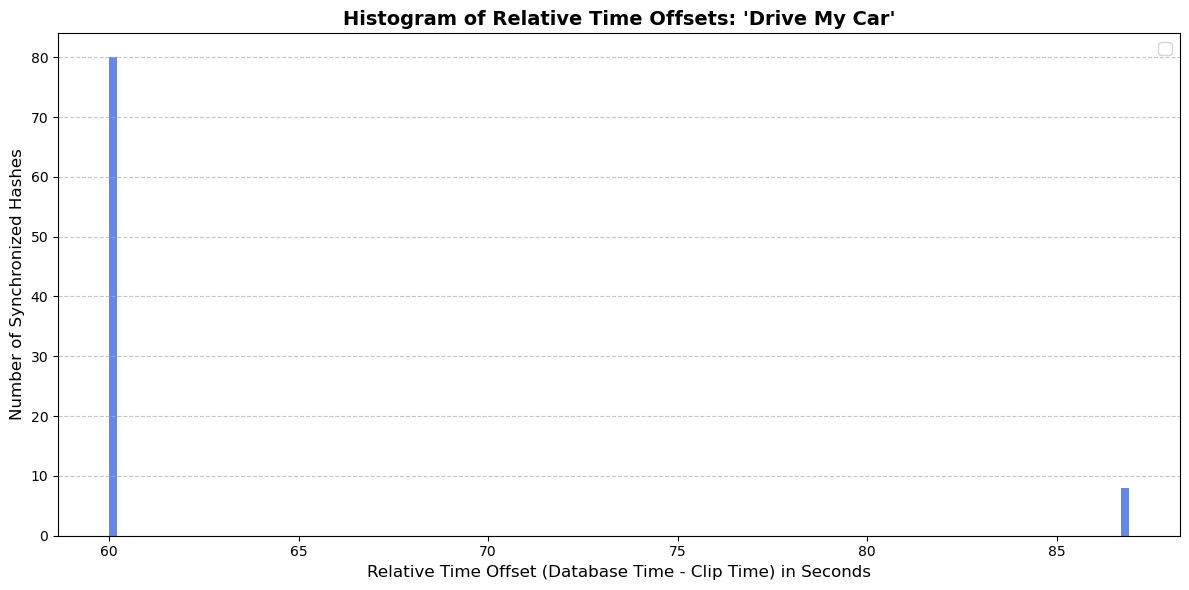

In [38]:
temp_file_1 = "unknown_clip_with_noise.wav"
add_noise(unknown_path,0.4)
song_name, histogram = match_audio_clip(temp_file_1, DATABASE_FILE)
plot_offset_histogram(histogram, song_name)


1)Adding Noise

Noise Level: 100% of max amplitude
Analyzing unknown clip: 'unknown_clip_with_noise.wav'...
----------------------------------------
✅ MATCH FOUND: Bohemian Rhapsody
   -> Alignment Score: 9 synchronized hashes
   -> Clip starts at ~232.7 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


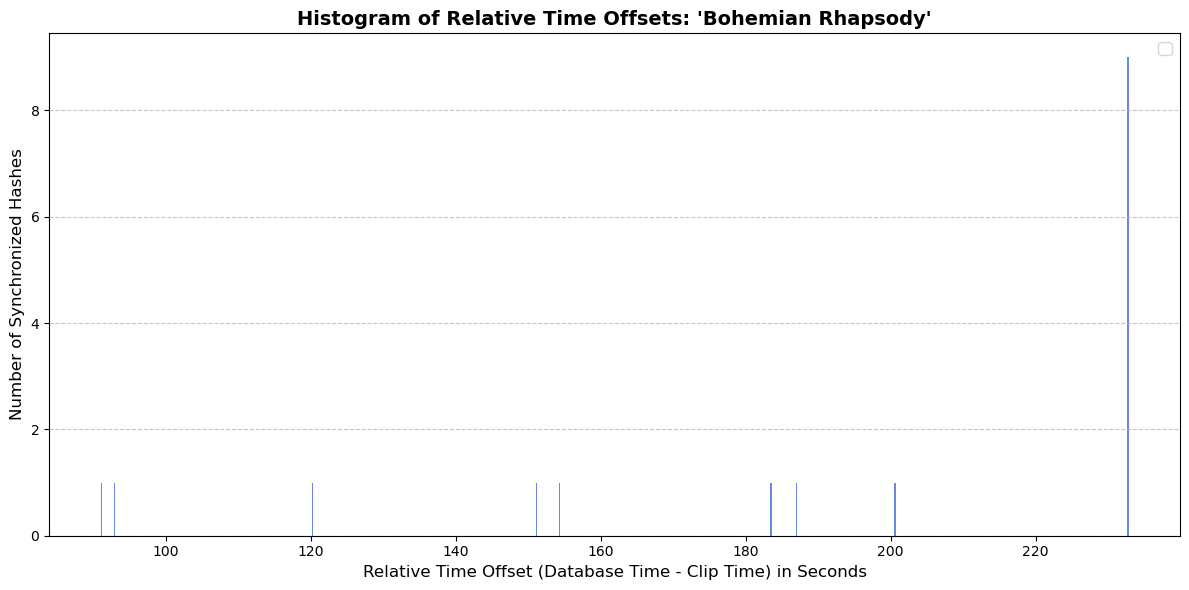

In [51]:
temp_file_1 = "unknown_clip_with_noise.wav"
add_noise(unknown_path,1)
song_name, histogram = match_audio_clip(temp_file_1, DATABASE_FILE)
plot_offset_histogram(histogram, song_name)

2)PITCH SHIFTING 

Pitch Shift: +0.01 semitones
Analyzing unknown clip: 'unknown_clip_with_shiftedpitch.wav'...
----------------------------------------
✅ MATCH FOUND: Drive My Car
   -> Alignment Score: 2016 synchronized hashes
   -> Clip starts at ~60.1 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


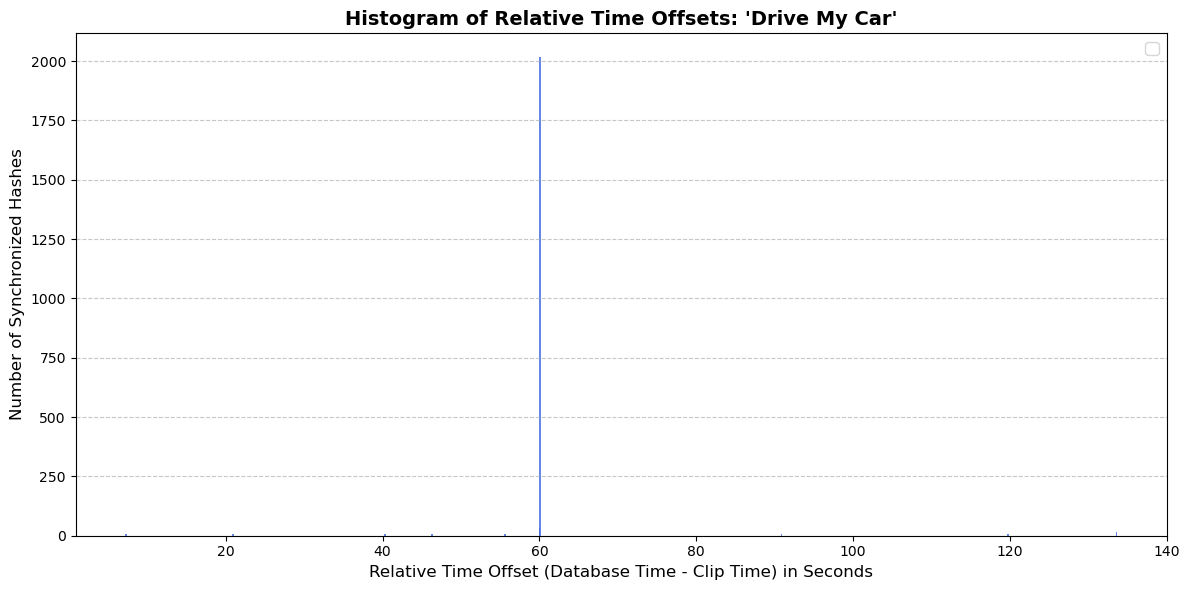

In [ ]:
temp_file_2 = "unknown_clip_with_shiftedpitch.wav"
add_shifted_pitch(unknown_path,0.01)

song_name, histogram = match_audio_clip(temp_file_2, DATABASE_FILE)
plot_offset_histogram(histogram, song_name)

2)PITCH SHIFTING 

Pitch Shift: +0.05 semitones
Analyzing unknown clip: 'unknown_clip_with_shiftedpitch.wav'...
----------------------------------------
✅ MATCH FOUND: Drive My Car
   -> Alignment Score: 96 synchronized hashes
   -> Clip starts at ~60.1 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


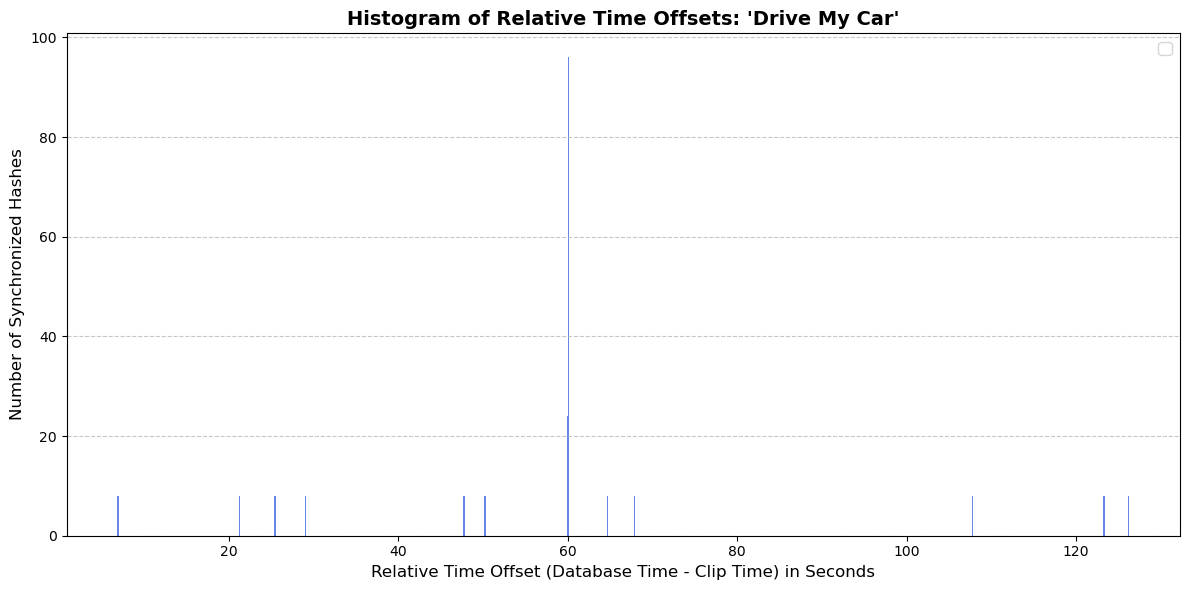

In [40]:
temp_file_2 = "unknown_clip_with_shiftedpitch.wav"
add_shifted_pitch(unknown_path,0.05)
song_name, histogram = match_audio_clip(temp_file_2, DATABASE_FILE)
plot_offset_histogram(histogram, song_name)

2)PITCH SHIFTING 

Pitch Shift: +0.2 semitones
Analyzing unknown clip: 'unknown_clip_with_shiftedpitch.wav'...
----------------------------------------
✅ MATCH FOUND: A Day In The Life
   -> Alignment Score: 10 synchronized hashes
   -> Clip starts at ~17.5 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


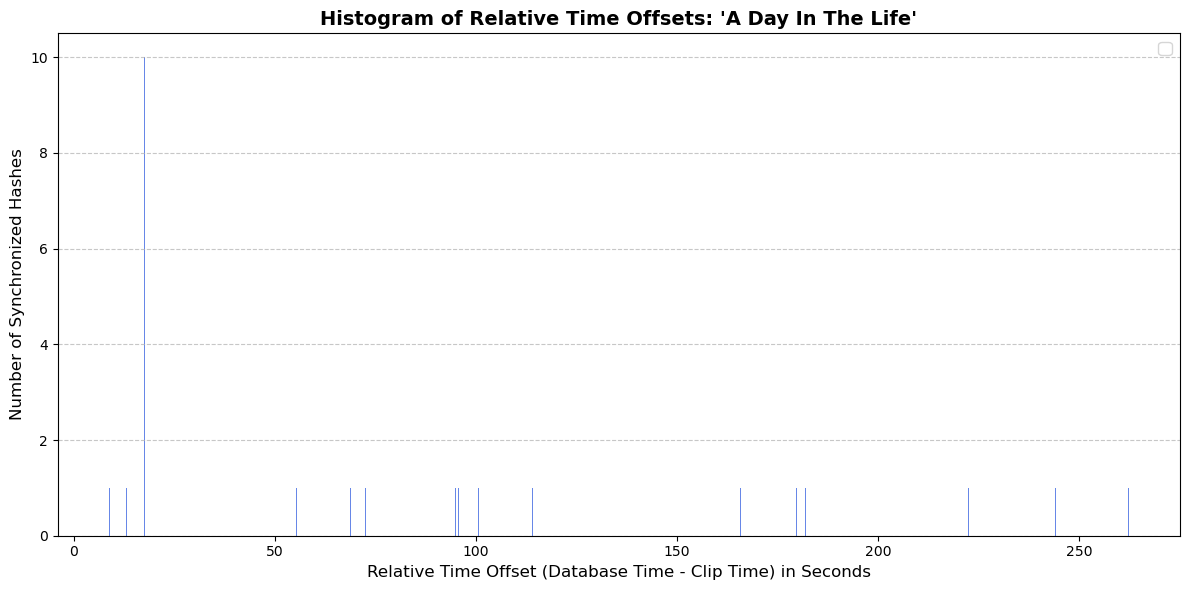

In [41]:
temp_file_2 = "unknown_clip_with_shiftedpitch.wav"
add_shifted_pitch(unknown_path,0.2)
song_name, histogram = match_audio_clip(temp_file_2, DATABASE_FILE)
plot_offset_histogram(histogram, song_name)

3) TIME STRETCHING

Time Stretch: 1.02x speed
Analyzing unknown clip: 'unknown_clip_with_stretched_time.wav'...


----------------------------------------
✅ MATCH FOUND: Drive My Car
   -> Alignment Score: 320 synchronized hashes
   -> Clip starts at ~60.1 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


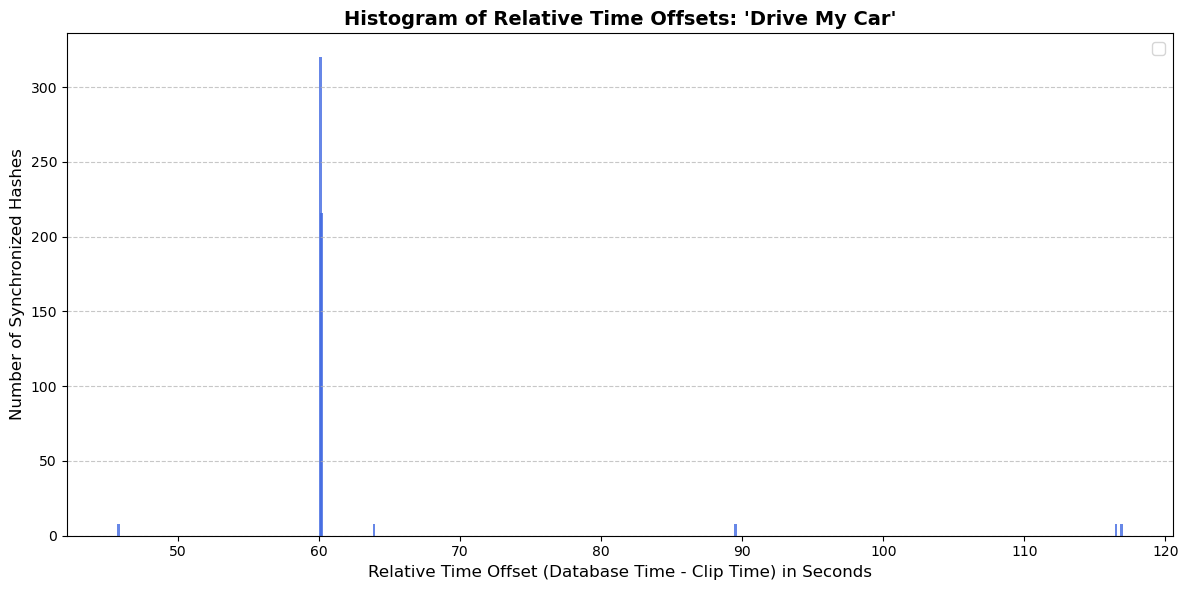

In [42]:
temp_file_3 = "unknown_clip_with_stretched_time.wav"
add_streteched_time(unknown_path,1.02)
song_name, histogram = match_audio_clip(temp_file_3, DATABASE_FILE)
plot_offset_histogram(histogram,song_name )

3) TIME STRETCHING

Time Stretch: 1.2x speed
Analyzing unknown clip: 'unknown_clip_with_stretched_time.wav'...
----------------------------------------
✅ MATCH FOUND: A Day In The Life
   -> Alignment Score: 9 synchronized hashes
   -> Clip starts at ~75.4 seconds into the song
----------------------------------------


C:\Users\manth\AppData\Local\Temp\ipykernel_24948\2364487228.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


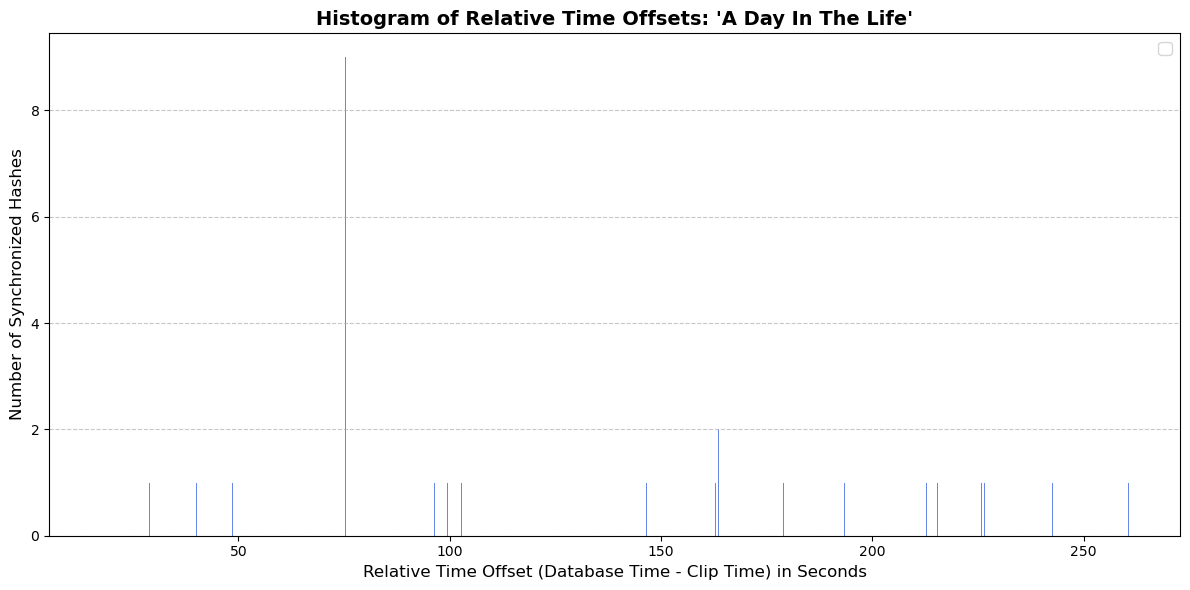

In [43]:
temp_file_3 = "unknown_clip_with_stretched_time.wav"
add_streteched_time(unknown_path,1.2)
song_name, histogram = match_audio_clip(temp_file_3, DATABASE_FILE)
plot_offset_histogram(histogram,song_name )